### В данном уроке мы выделим еще несколько потенциально важных фичей из изначального датасета и попробуем применить изученные методы отбора признаков к итоговому датасету.

In [1]:
import numpy as np
import pandas as pd

processed_data = pd.read_csv('data/processed_data.csv', index_col='id')

processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration
id,,,,,
id2875421,1,930.399753,0,1.500479,6.122493
id2377394,0,930.399753,0,1.807119,6.498282
id3858529,1,930.399753,0,6.392080,7.661527
id3504673,1,930.399753,0,1.487155,6.063785
id2181028,1,930.399753,0,1.189925,6.077642


In [2]:
initial_data = pd.read_csv('data/taxi_dataset.csv')

initial_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N


In [3]:
initial_data.shape[0] == processed_data.shape[0]

False

In [4]:
### Вернем в датасет колонку pickup_datetime

initial_data = initial_data.set_index('id')

processed_data = pd.merge(processed_data, initial_data['pickup_datetime'],
                          left_index=True, right_index=True)

In [5]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime
id,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55


Напомним, **pickup_datetime** - время начала поездки.

Кажется, что в зависимости от месяца/дня недели/времени суток движение на дорогах может отличаться. Как из-за погодных условий, так и из-за загруженности транспорта. Поэтому, есть подозрение, что будет полезно выделить ряд признаков из колонки **pickup_datetime**. Давайте исследуем зависимость нашей таргетной переменной от указанных факторов.

In [6]:
processed_data['pickup_datetime'] = pd.to_datetime(processed_data['pickup_datetime'])

processed_data['date'] = processed_data.pickup_datetime.dt.date
processed_data['day_of_week'] = processed_data.pickup_datetime.dt.dayofweek
processed_data['hour'] = processed_data.pickup_datetime.dt.hour
processed_data['month'] = processed_data.pickup_datetime.dt.month

In [7]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month
id,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55,2016-03-14,0,17,3
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35,2016-06-12,6,0,6
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31,2016-04-06,2,19,4
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55,2016-03-26,5,13,3


Исследуем, когда и сколько поездок было совершено. 

Начнем с графиков, показывающих количество поездок в зависимости от времени суток/даты и т.д.

Так же полезно сразу показать и среднее значение таргетной переменной.

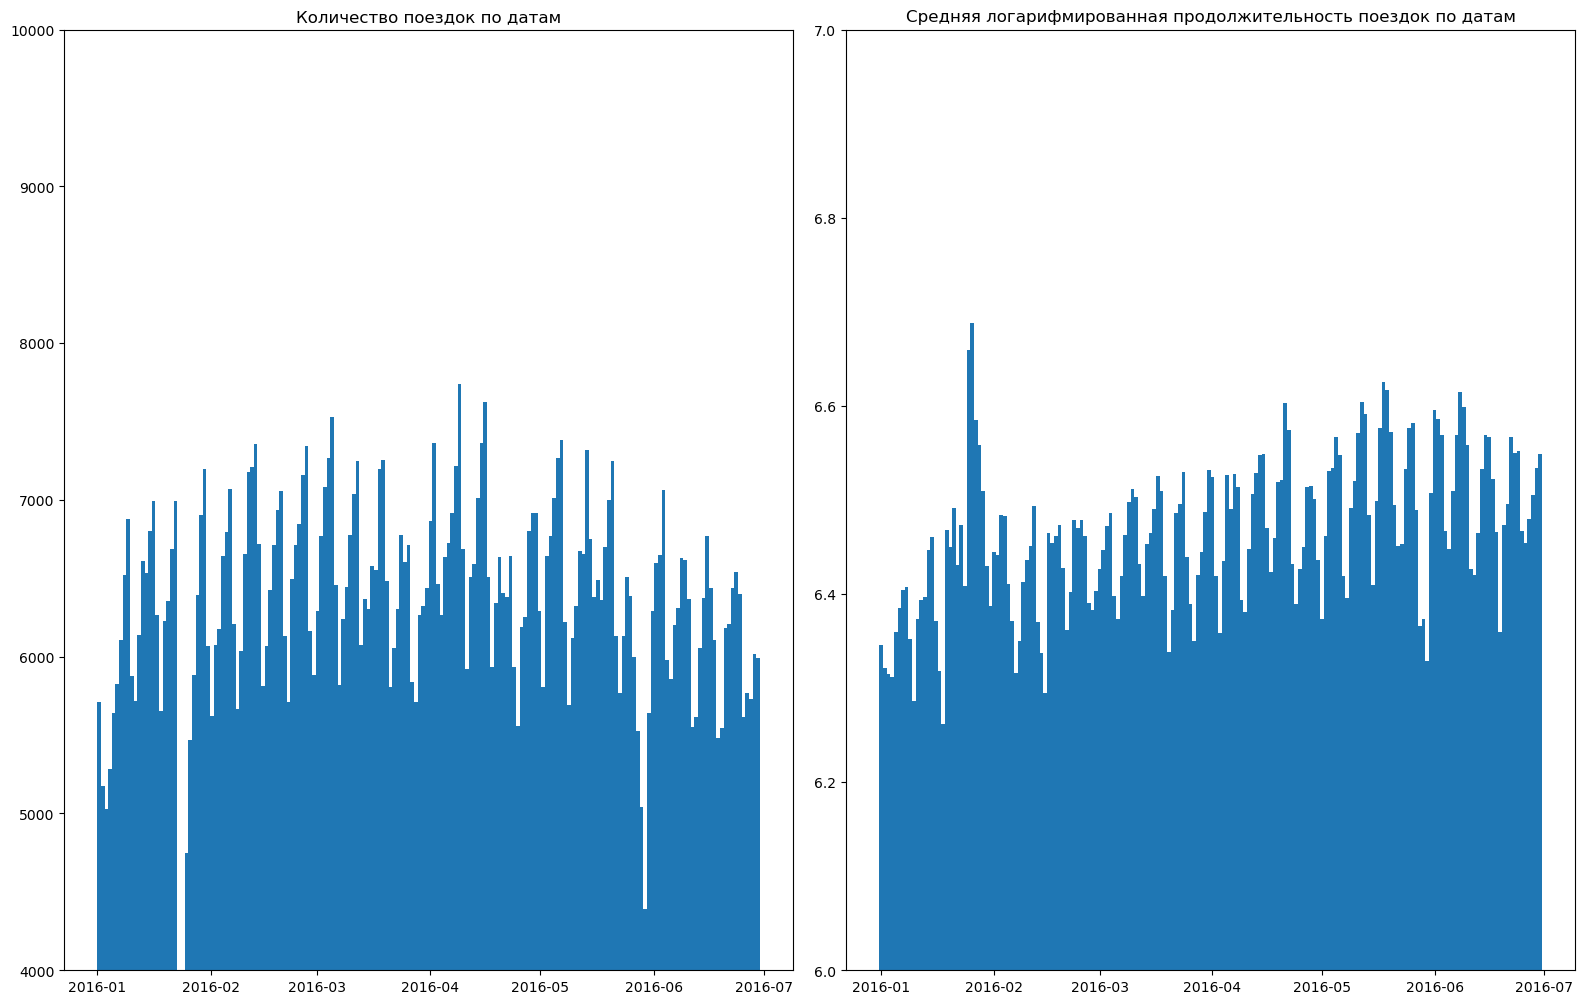

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

ax_1 = fig.add_subplot(1, 2, 1)
plt.hist(processed_data['date'], bins=processed_data.date.unique().shape[0])
plt.ylim((4000, 10000))

ax_2 = fig.add_subplot(1, 2, 2)
plt.bar(sorted(list(processed_data['date'].unique())), 
        processed_data.groupby('date', as_index=False)['log_trip_duration'].mean()['log_trip_duration'],
        width=1)
plt.ylim((6, 7))

fig.tight_layout()

ax_1.set(title = 'Количество поездок по датам')
ax_2.set(title = 'Средняя логарифмированная продолжительность поездок по датам')

plt.show()

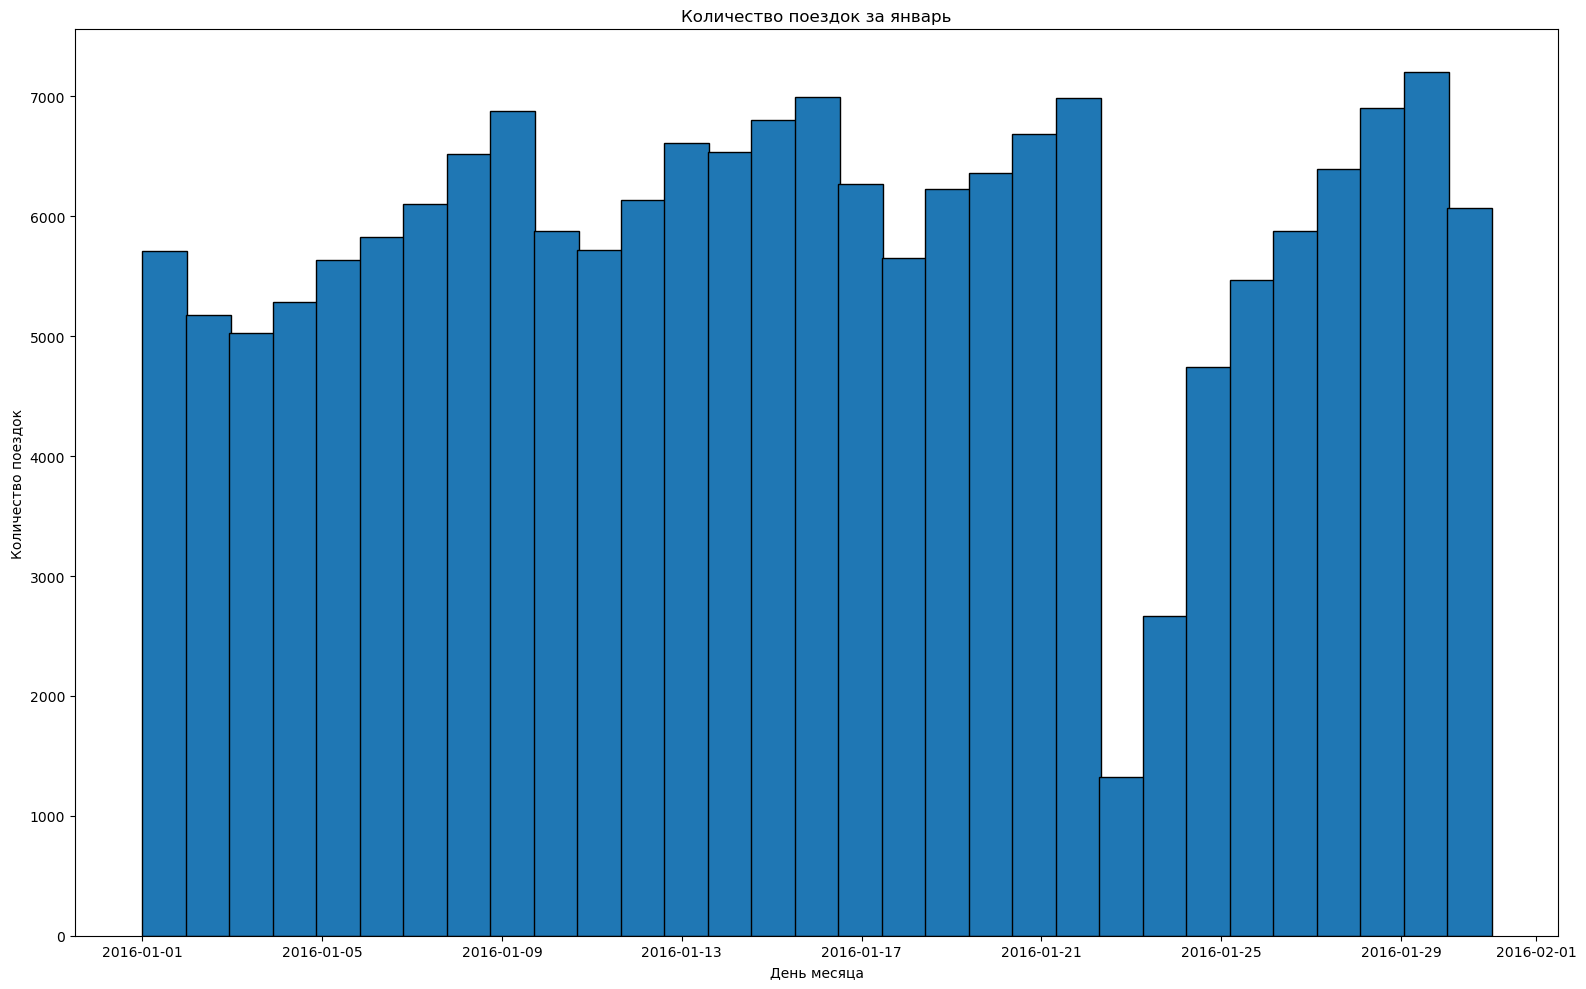

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)


plt.hist(processed_data[processed_data['month']==1]['date'], bins=processed_data[processed_data['month']==1].date.unique().shape[0]
         ,width=1, edgecolor='black')
plt.ylim()



plt.xlabel('День месяца')
plt.ylabel('Количество поездок')
plt.title('Количество поездок за январь')
fig.tight_layout()

plt.show()

Кажется, что внутри недели есть некоторая зависимость таргета от дня недели. 

Такая же зависимость может оказаться и внутри дня (в завимости от часов).

Предлагаю исследовать эту зависимость подробнее.

Изобразите следующие графики зависимостей:

- Количество поездок/Средняя продолжительность поездки vs День недели
- Количество поездок/Средняя продолжительность поездки vs время суток
- Средняя продолжительность поездки vs время суток для каждого дня недели (например, нарисовав с разными цветами и, соответственно, легендами)
- Аналогичные графики, используя информацию о месяце, внутри которого была совершена поездка.
- Ящики с усами для различных: времени суток, дня недели, месяца

Используйте любые доступные инструменты pyplot!

Далее, на основе полученных результатов, мы будем принимать решение о создании новых признаков.

EDA можно использовать не только для того, чтобы понять, какие фичи можно убрать из датасета. Но и для выделения базовых признаков. Этим и займемся!

P.S. Сами графики мы проверять у Вас не будем. Зато для ответа на устные вопросы понадобятся, поэтому, в любом случае, крайне рекомендуем поупражняться. Поэтому рисовать все графики не обязательно - ограничьтесь теми, которые помогут Вам ответить на тестовые вопросы.

**Hint**: обратите внимание на сильную просадку в январе. Почему она могла произойти - можно прочитать <a href="https://en.wikipedia.org/wiki/January_2016_United_States_blizzard"> здесь</a>. В будущем можно будет создать бинарный признак "произошла ли поездка во время сильного снегопада".


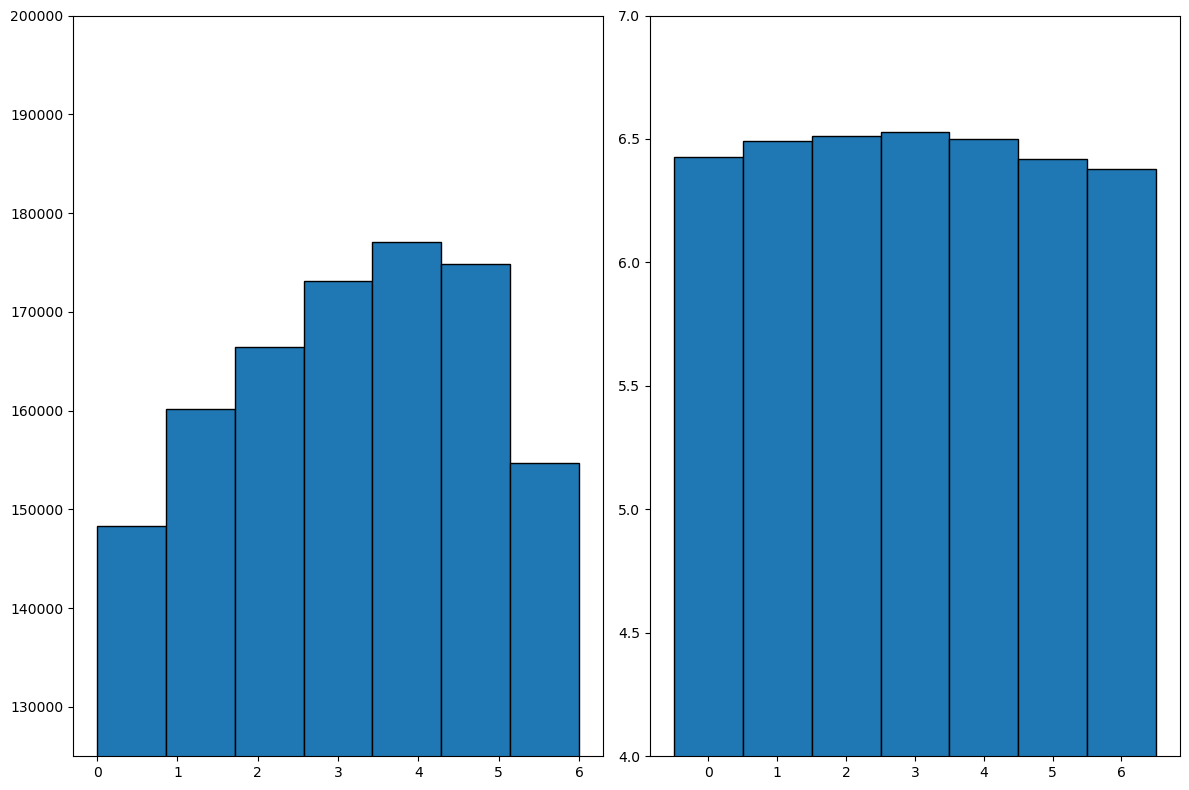

In [10]:
### Построим график Количество поездок/Средняя продолжительность поездки vs День недели
fig = plt.figure()
fig.set_size_inches(12, 8)

ax1 = fig.add_subplot(1,2,1)

plt.hist(processed_data['day_of_week'], bins=processed_data.day_of_week.unique().shape[0], edgecolor='black')

plt.ylim(125000,200000)

ax2 = fig.add_subplot(1,2,2)

plt.bar(sorted(list(processed_data['day_of_week'].unique())), 
        processed_data.groupby('day_of_week', as_index=False)['log_trip_duration'].mean()['log_trip_duration'],
        width=1, edgecolor='black')
plt.ylim((4, 7))

fig.tight_layout()

ax_1.set(title = 'Количество поездок по дням недели')
ax_2.set(title = 'Средняя логарифмированная продолжительность поездок по дням недели')

plt.show()


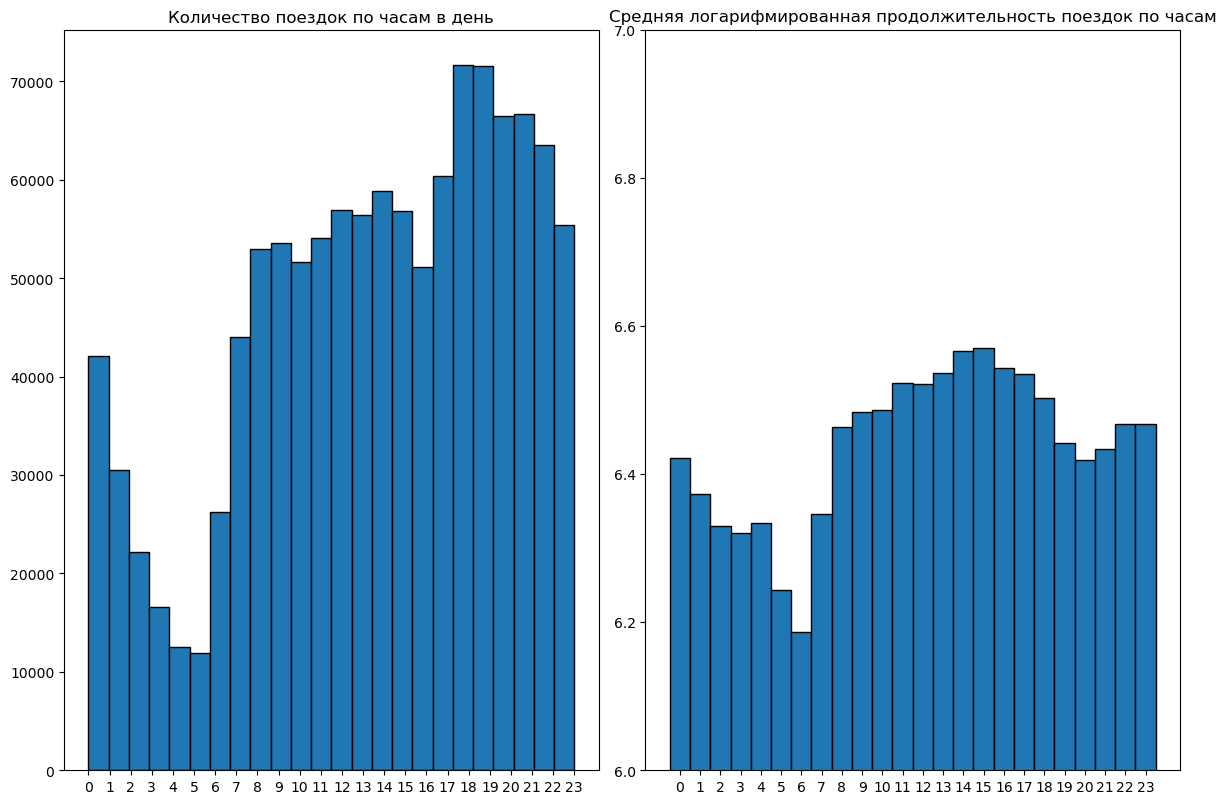

In [11]:
### Построим график Количество поездок/Средняя продолжительность поездки vs Время суток
fig = plt.figure()
fig.set_size_inches(12, 8)

ax1 = fig.add_subplot(1,2,1)

plt.hist(processed_data['hour'], bins=processed_data.hour.unique().shape[0], edgecolor='black')

plt.ylim()

ax2 = fig.add_subplot(1,2,2)

plt.bar(sorted(list(processed_data['hour'].unique())), 
        processed_data.groupby('hour', as_index=False)['log_trip_duration'].mean()['log_trip_duration'],
        width=1, edgecolor='black')
plt.ylim(6,7)

fig.tight_layout()

ax1.set(title = 'Количество поездок по часам в день')
ax2.set(title = 'Средняя логарифмированная продолжительность поездок по часам')
ax1.set_xticks(range(processed_data.hour.unique().shape[0])) # ставим указатели на часы, типа ось x
ax2.set_xticks(range(processed_data.hour.unique().shape[0])) #

plt.show()



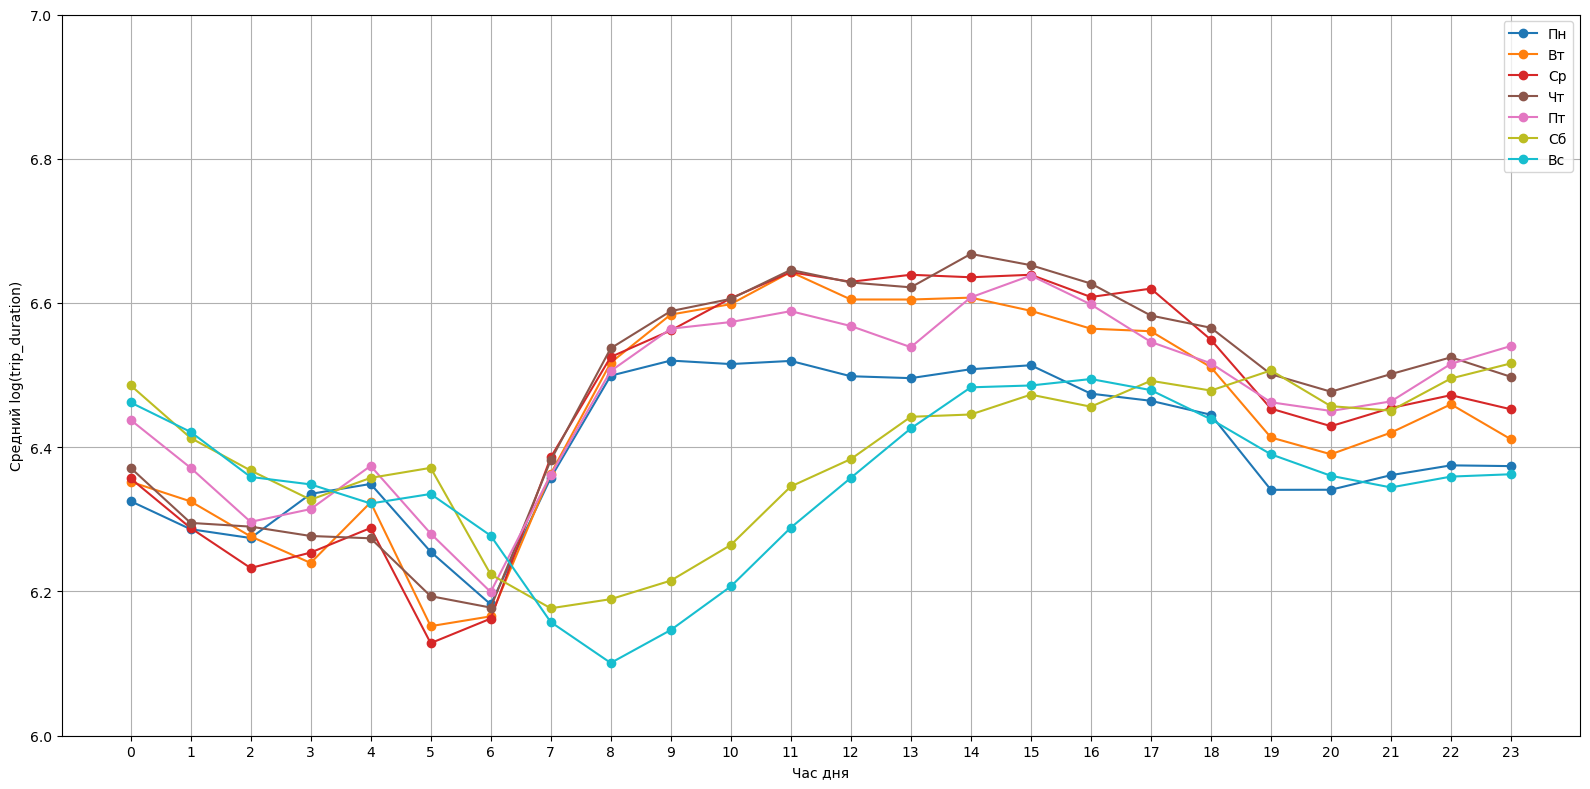

In [13]:
### Средняя продолжительность поездки vs время суток для каждого дня недели (например, нарисовав с разными цветами и, соответственно, легендами)
fig = plt.figure()
fig.set_size_inches(16, 8)

days = sorted(list(processed_data['day_of_week'].unique()))
colors = plt.cm.tab10(np.linspace(0, 1, len(days)))

for day in days:
    
    day_data = processed_data[processed_data['day_of_week'] == day]
    mean_by_hour = day_data.groupby('hour')['log_trip_duration'].mean()
    
    plt.plot(mean_by_hour.index, mean_by_hour.values, 
             marker='o', label=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'][day], color=colors[day])

plt.xticks(range(0, 24, 1))  # Отсечки каждый час
plt.ylim(6, 7)
plt.xlabel('Час дня')
plt.ylabel('Средний log(trip_duration)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


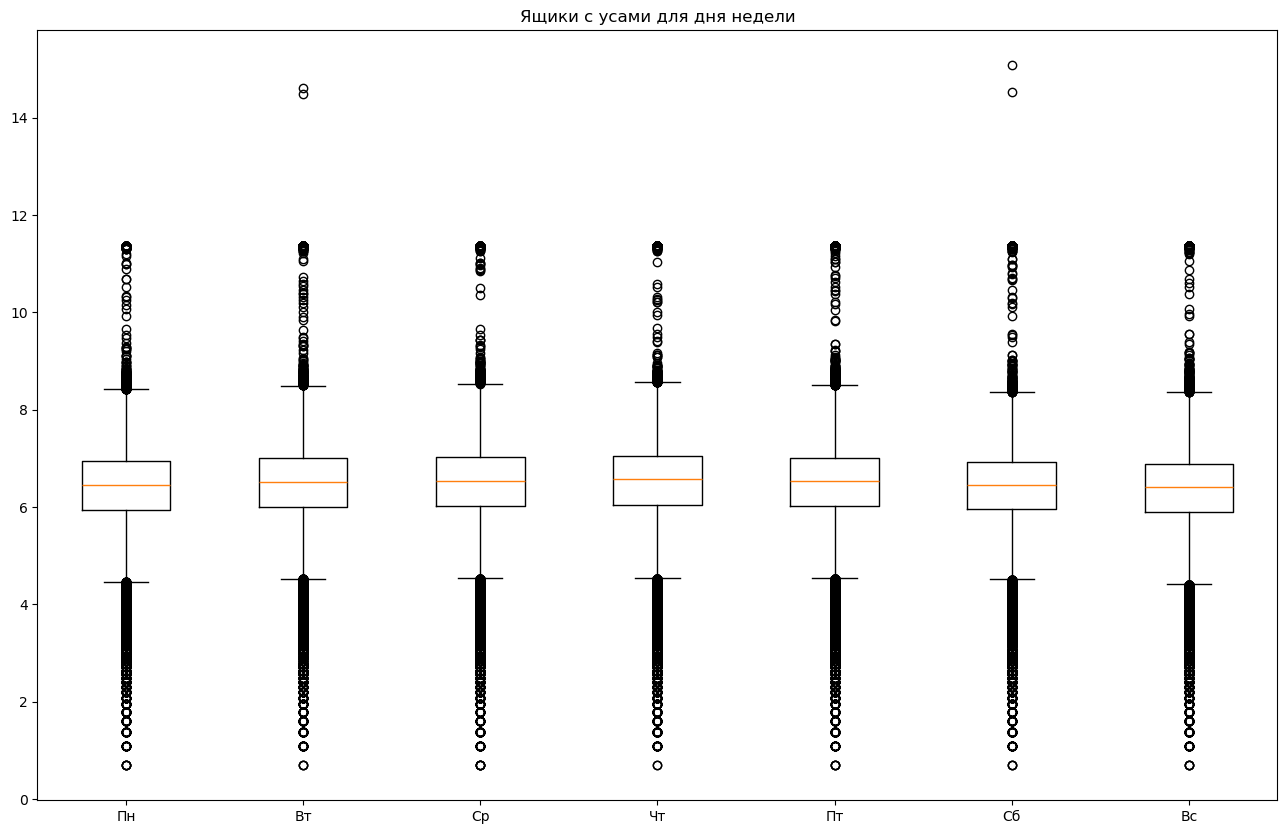

In [14]:
#Ящики с усами для дня недели
day_dict = {}
day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}

for day in sorted(list(processed_data['day_of_week'].unique())):
    
    day_dict[day] = processed_data[processed_data['day_of_week']==day]['log_trip_duration']

fig = plt.figure()
fig.set_size_inches(16, 10)

plt.boxplot(day_dict.values(),
            tick_labels=[day_names[day] for day in day_dict.keys()])

plt.ylim()
plt.title('Ящики с усами для дня недели')
plt.show()

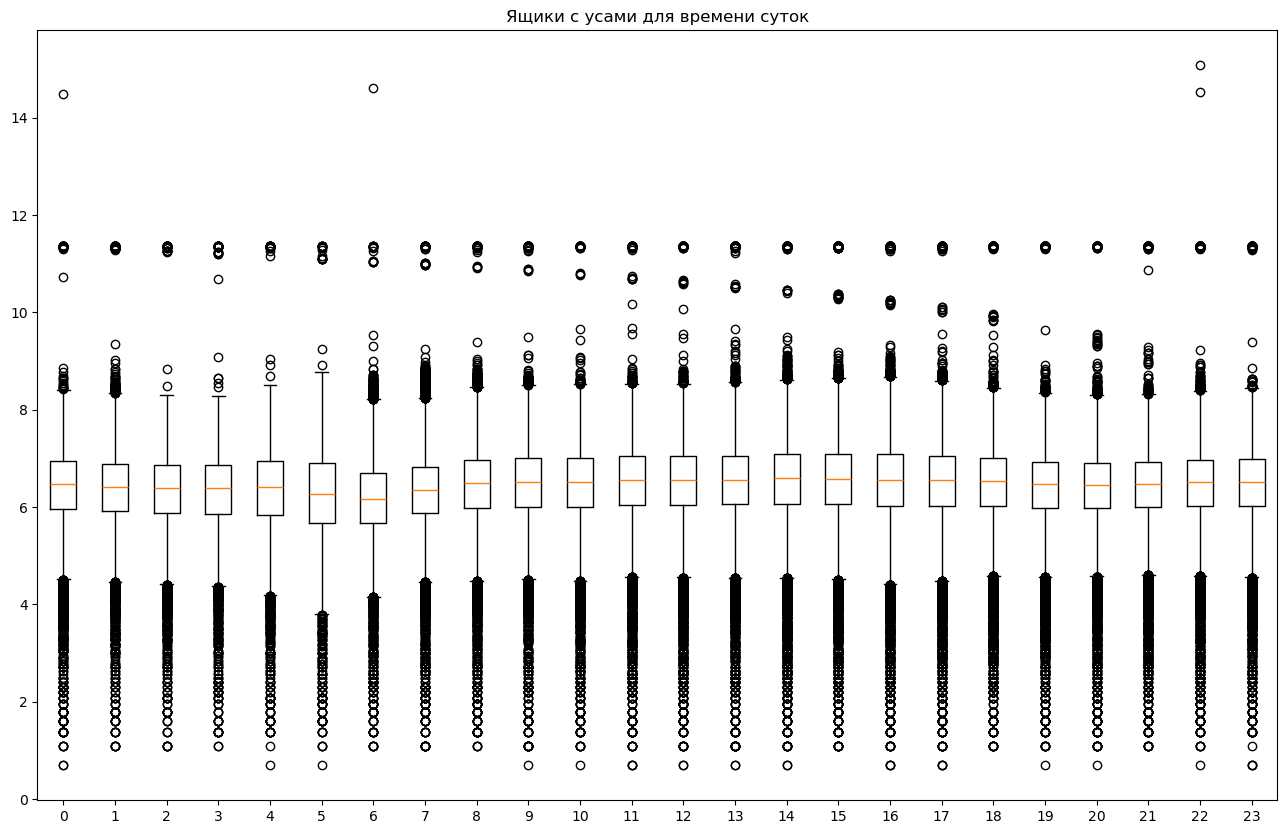

In [15]:
#Ящики с усами времени суток
hour_dict = {}


for hour in sorted(list(processed_data['hour'].unique())):
    
    hour_dict[hour] = processed_data[processed_data['hour']==hour]['log_trip_duration']

fig = plt.figure()
fig.set_size_inches(16, 10)

plt.boxplot(hour_dict.values(),
            tick_labels=hour_dict.keys())

plt.ylim()
plt.title('Ящики с усами для времени суток')
plt.show()

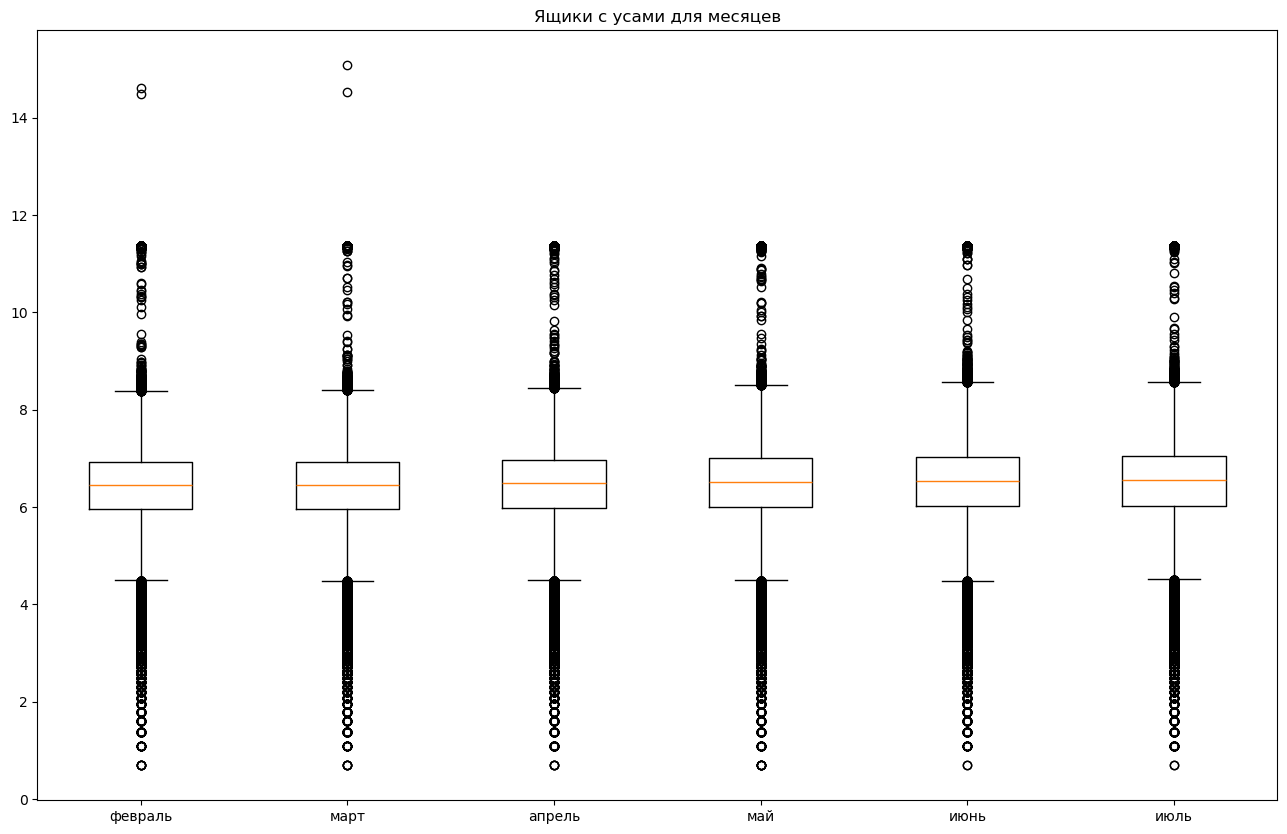

In [16]:
#Ящики с усами для месяцев
month_dict = {}
month_names = {0: 'январь', 1: 'февраль', 2: 'март', 3: 'апрель', 4: 'май', 5: 'июнь', 6: 'июль',
             7: 'Август', 8: 'Сентябрь', 9: 'Октябрь', 10: 'Ноябрь', 11: 'Февраль'}

for month in sorted(list(processed_data['month'].unique())):
    
    month_dict[month] = processed_data[processed_data['month']==month]['log_trip_duration']

fig = plt.figure()
fig.set_size_inches(16, 10)

plt.boxplot(month_dict.values(),
            tick_labels=[month_names[month] for month in month_dict.keys()])

plt.ylim()
plt.title('Ящики с усами для месяцев')
plt.show()

Кажется, что полученные выводы из графиков выше достаточны для того, чтобы посчитать признаки, связанные с временем/датой поездки, достаточно важными. На их основе выделим еще пару.

Добавьте следующие бинарные признаки:


1. Была ли в день поездки буря (основываясь на единственном обнаруженном таком дне)
2. Является ли время поездки статистически самым проблемным, то есть час пиком?

Для создания 2ой фичи используйте следующую логику: посчитаем для каждой пары "день недели"-"время суток" среднее значение таргета. Найдем топ-10 самых "больших" пар. Если поездка была совершена во входящее в этот топ время, то ставим 1. Иначе - 0. Получается бинарный признак.

P.S. назовите колонки **anomaly** и **traffic_jam**

In [17]:
find_tornado = processed_data.groupby(['month', 'date'],as_index=False).count()
find_tornado[find_tornado['vendor_id']<1500]['date']

22    2016-01-23
Name: date, dtype: object

In [18]:
processed_data.dtypes

vendor_id                      int64
passenger_count              float64
store_and_fwd_flag             int64
distance_km                  float64
log_trip_duration            float64
pickup_datetime       datetime64[ns]
date                          object
day_of_week                    int32
hour                           int32
month                          int32
dtype: object

In [19]:
### Создадим первый бинарный признак
processed_data['tornado']=0
processed_data['date'] = pd.to_datetime(processed_data['date'])
processed_data.loc[processed_data['date'] == '2016-01-23', 'tornado'] = 1

In [20]:
processed_data[processed_data['tornado']==1]

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month,tornado
id,,,,,,,,,,,
id1027675,1,930.399753,0,1.001201,7.088409,2016-01-23 08:46:42,2016-01-23,5,8,1,1
id2657420,0,930.399753,0,7.044418,7.163172,2016-01-23 00:06:25,2016-01-23,5,0,1,1
id3382236,1,1070.232174,0,1.268585,5.808142,2016-01-23 10:38:43,2016-01-23,5,10,1,1
id2636301,1,930.399753,0,3.689727,6.885510,2016-01-23 01:16:58,2016-01-23,5,1,1,1
id0252677,1,1070.232174,0,3.358010,6.889591,2016-01-23 00:19:01,2016-01-23,5,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
id3981705,1,1070.232174,0,4.076017,7.038784,2016-01-23 07:58:16,2016-01-23,5,7,1,1
id3083039,0,930.399753,0,2.090501,6.613384,2016-01-23 13:37:20,2016-01-23,5,13,1,1
id0547209,1,1005.458335,0,1.054028,5.978886,2016-01-23 07:40:07,2016-01-23,5,7,1,1


In [21]:
processed_data.rename({'tornado':'anomaly'}, axis=1,inplace=True)

In [22]:
processed_data

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month,anomaly
id,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55,2016-03-14,0,17,3,0
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35,2016-06-12,6,0,6,0
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1,0
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31,2016-04-06,2,19,4,0
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55,2016-03-26,5,13,3,0
...,...,...,...,...,...,...,...,...,...,...,...
id0509606,0,930.399753,0,1.501333,6.169611,2016-02-25 21:41:07,2016-02-25,3,21,2,0
id1838531,0,930.399753,0,2.085663,6.539586,2016-03-08 08:05:56,2016-03-08,1,8,3,0
id1749707,0,930.399753,0,4.886822,7.374002,2016-04-23 12:20:27,2016-04-23,5,12,4,0


In [23]:
### Создадим второй бинарный признак
### Для создания 2ой фичи используйте следующую логику: посчитаем для каждой пары "день недели"-"время суток" среднее значение таргета. 
### Найдем топ-10 самых "больших" пар. 
### Если поездка была совершена во входящее в этот топ время, то ставим 1. Иначе - 0. Получается бинарный признак
top_10 = processed_data.groupby(['day_of_week', 'hour'], as_index=False).mean().sort_values('log_trip_duration', ascending=False).head(10)[['day_of_week','hour']]
top_10

,day_of_week,hour
86,3,14
87,3,15
83,3,11
35,1,11
59,2,11
63,2,15
61,2,13
111,4,15
62,2,14
60,2,12


In [24]:
top_10 = processed_data.groupby(['day_of_week', 'hour'], as_index=False).mean().sort_values('log_trip_duration', ascending=False).head(10)[['day_of_week','hour']]
day_of_week = list(top_10['day_of_week'])
hour = list(top_10['hour'])
zip_top_10 = list(zip(day_of_week, hour))  # Сохраняем в список

processed_data['traffic_jam'] = 1

for day, hour in zip_top_10:
    processed_data.loc[(processed_data['day_of_week'] == day) & (processed_data['hour'] == hour), 'traffic_jam'] = 0

processed_data[processed_data['traffic_jam'] == 0]

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month,anomaly,traffic_jam
id,,,,,,,,,,,,
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1,0,0
id1410897,0,930.399753,0,9.951986,7.754482,2016-03-23 14:10:39,2016-03-23,2,14,3,0,0
id2569332,0,930.399753,0,1.154389,5.902633,2016-04-13 14:24:47,2016-04-13,2,14,4,0,0
id3827863,1,1028.236276,0,3.849593,8.168770,2016-04-19 11:29:08,2016-04-19,1,11,4,0,0
id1082443,1,930.399753,0,1.363568,6.666957,2016-02-25 14:56:26,2016-02-25,3,14,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
id1177002,0,930.399753,0,0.765698,5.905362,2016-02-18 14:26:47,2016-02-18,3,14,2,0,0
id3503475,0,930.399753,0,1.265096,6.413459,2016-01-27 12:04:52,2016-01-27,2,12,1,0,0
id3532829,1,930.399753,0,0.618900,6.148468,2016-03-23 13:22:29,2016-03-23,2,13,3,0,0


In [25]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month,anomaly,traffic_jam
id,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55,2016-03-14,0,17,3,0,1
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35,2016-06-12,6,0,6,0,1
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1,0,0
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31,2016-04-06,2,19,4,0,1
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55,2016-03-26,5,13,3,0,1


Теперь колонки **pickup_datetime**, **date** можно убрать. А про оставшиеся **day_of_week**, **hour**, **month** необходимо подумать:

- С одной стороны, первые две можно убрать, так как на их основе была создана колонка **traffic_jam**
- С другой стороны, зависимость с колонкой **traffic_jam** нелинейная, поэтому можно попробовать использовать все фичи в комбинации. Конечно, лучше попробовать оба варианта и проэкспериментировать, но ради упрощения - оставим все колонки. Хоть **day_of_week**, **hour** и описываются числами, мы понимаем, что это скорее категориальные фичи. Потому что, например, отношение между 23:00 и 00:00 не такое же, как между числами 23 и 0. Закодируем их с помощью OneHotEncoder. 
- Последняя (**month**) очевидно категориальная. Можно закодировать ее тоже через OneHotEncoder.

In [26]:
processed_data = processed_data.drop(['pickup_datetime', 'date'], axis=1)

In [27]:
### Делаем OneHotEncoding и конкатим с processed_data


for col in ['day_of_week', 'hour', 'month']:
    
    ### Your code is here
    one_hot = pd.get_dummies(processed_data[col], prefix=col, drop_first=True)
    processed_data = pd.concat((processed_data.drop(col, axis=1), one_hot), axis=1)



In [28]:
processed_data['day_of_week_1'].astype(int)

id
id2875421    0
id2377394    0
id3858529    1
id3504673    0
id2181028    0
            ..
id0509606    0
id1838531    1
id1749707    0
id3577557    0
id3313693    0
Name: day_of_week_1, Length: 1154491, dtype: int32

In [29]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,anomaly,traffic_jam,day_of_week_1,day_of_week_2,day_of_week_3,...,hour_19,hour_20,hour_21,hour_22,hour_23,month_2,month_3,month_4,month_5,month_6
id,,,,,,,,,,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,0,1,False,False,False,...,False,False,False,False,False,False,True,False,False,False
id2377394,0,930.399753,0,1.807119,6.498282,0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True
id3858529,1,930.399753,0,6.392080,7.661527,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
id3504673,1,930.399753,0,1.487155,6.063785,0,1,False,True,False,...,True,False,False,False,False,False,False,True,False,False
id2181028,1,930.399753,0,1.189925,6.077642,0,1,False,False,False,...,False,False,False,False,False,False,True,False,False,False


Что же, мы с Вами научились с помощью EDA визуализаций понимать важность признаков не только постфактум, но и до того, как сформировался финальный датасет - на этапе **выделения базовых фичей**.

Обратимся теперь к методам фильтрации - например, применим корреляционный анализ для одной пары фичей, чтобы понять, нет ли относительно этих колонок в нашем датасете избытка информации. 

Вспомним так же изначальные вещественные признаки - distance_km, passenger_count

Посчитайте корреляцию между ними. Есть ли какие-то основания для беспокойства?

In [30]:
### Your code is here
processed_data[['distance_km','passenger_count']].corr().round(3)


,distance_km,passenger_count
distance_km,1.000,0.016
passenger_count,0.016,1.000


In [31]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,anomaly,traffic_jam,day_of_week_1,day_of_week_2,day_of_week_3,...,hour_19,hour_20,hour_21,hour_22,hour_23,month_2,month_3,month_4,month_5,month_6
id,,,,,,,,,,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,0,1,False,False,False,...,False,False,False,False,False,False,True,False,False,False
id2377394,0,930.399753,0,1.807119,6.498282,0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True
id3858529,1,930.399753,0,6.392080,7.661527,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
id3504673,1,930.399753,0,1.487155,6.063785,0,1,False,True,False,...,True,False,False,False,False,False,False,True,False,False
id2181028,1,930.399753,0,1.189925,6.077642,0,1,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [32]:
### На данный момент у нас 41 фича
### Представим, что хочется сократить их количество до 5.
### Воспользуемся для этим каким-нибудь методом обертки
### Например, метод прямого отбора

### Your code is here
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

X = processed_data.drop('log_trip_duration', axis=1)
Y = processed_data['log_trip_duration']

model=LinearRegression()


sfs = SequentialFeatureSelector(model, n_features_to_select=5)
sfs.fit(X,Y)

sfs.get_feature_names_out()

array(['distance_km', 'traffic_jam', 'day_of_week_6', 'hour_5', 'hour_6'],
      dtype=object)

In [34]:
### Представим, что мы с Вами ничего не знаем про Кросс-Валидацию и отложенную выборку
### Замерьте качество линейной регрессии на данных фичах
### Сильно ли оно отличается от полученного на Кросс-Валидации в прошлом уроке в ДЗ?

### Your code is here
X_1=processed_data[['distance_km', 'traffic_jam', 'day_of_week_6', 'hour_5', 'hour_6']]
Y_1=Y
model.fit(X_1,Y_1)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
losses_test = np.mean((model.predict(X_1)-Y_1)**2)

In [36]:
losses_test.round(3)

0.423